In [1]:
# CÉLULA 1: Gerador de Dados (Gera o arquivo transacoes.csv automaticamente)
import csv

dados_csv = [
    ["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"],
    # 15 REGISTROS VÁLIDOS (Distribuídos em Jan, Fev e Mar)
    ["1", "2026-01-05", "CLI001", "credito", "3500.00", "Salário janeiro", "salario"],
    ["2", "2026-01-12", "CLI002", "debito", "180.50", "Supermercado", "compra"],
    ["3", "2026-01-15", "CLI003", "debito", "99.90", "Streaming", "assinatura"],
    ["4", "2026-01-22", "CLI001", "debito", "450.00", "Roupas", "compra"],
    ["5", "2026-01-28", "CLI004", "credito", "12500.00", "Venda de carro", "venda"], # > 10k
    ["6", "2026-02-03", "CLI002", "debito", "200.00", "Transferência", "transferencia"],
    ["7", "2026-02-10", "CLI001", "debito", "120.00", "Farmácia", "saude"],
    ["8", "2026-02-14", "CLI003", "credito", "15000.00", "Transferência suspeita", "transferencia"], # > 10k
    ["9", "2026-02-18", "CLI002", "debito", "320.00", "Conta de luz", "conta"],
    ["10", "2026-02-25", "CLI004", "debito", "800.00", "Manutenção", "servico"],
    ["11", "2026-03-01", "CLI001", "credito", "3500.00", "Salário março", "salario"],
    ["12", "2026-03-05", "CLI002", "debito", "150.00", "Internet", "conta"],
    ["13", "2026-03-10", "CLI003", "debito", "99.90", "Streaming", "assinatura"],
    ["14", "2026-03-15", "CLI004", "credito", "2000.00", "Rendimento", "investimento"],
    ["15", "2026-03-20", "CLI001", "debito", "300.00", "Restaurante", "lazer"],

    # 5 REGISTROS INVÁLIDOS (Para testar o try/except e validações)
    ["", "2026-01-20", "CLI001", "debito", "100.00", "ID Vazio", "erro"], # ID vazio
    ["17", "2026-02-03", "", "debito", "200.00", "Sem cliente", "transferencia"], # Cliente vazio
    ["18", "20-02-2026", "CLI002", "debito", "50.00", "Data errada", "erro"], # Data formato errado
    ["19", "2026-03-01", "CLI003", "pix", "100.00", "Tipo errado", "erro"], # Tipo diferente de credito/debito
    ["20", "2026-03-10", "CLI001", "debito", "abc", "Valor em texto", "erro"], # Valor não numérico
    ["21", "2026-03-12", "CLI002", "debito", "-50.00", "Valor negativo", "erro"] # Valor negativo (Bônus inválido)
]

with open("transacoes.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(dados_csv)

print("Arquivo 'transacoes.csv' criado com sucesso para o teste!")

Arquivo 'transacoes.csv' criado com sucesso para o teste!


In [2]:
# CÉLULA 2: Código Principal - Análise Nativa Python
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00

def validar_transacao(linha):
    """Valida uma linha do CSV. Retorna a linha formatada se válida, ou None se inválida."""
    try:
        # Validação de ID e Cliente
        if not linha['id'] or not linha['id'].isdigit(): return None
        if not linha['cliente_id'] or str(linha['cliente_id']).strip() == "": return None

        # Validação de Tipo
        if linha['tipo'] not in ['credito', 'debito']: return None

        # Validação e Conversão de Valor (Try/Except 1)
        try:
            valor = float(linha['valor'])
            if valor <= 0: return None
            linha['valor'] = valor
        except ValueError:
            return None

        # Validação e Conversão de Data (Try/Except 2)
        try:
            linha['data_obj'] = datetime.strptime(linha['data'], "%Y-%m-%d")
        except ValueError:
            return None

        return linha
    except Exception:
        return None

def ler_transacoes(caminho_arquivo):
    """Lê o arquivo CSV, conta válidos/inválidos e retorna lista de transações limpas."""
    transacoes_validas = []
    total_lidas = 0
    invalidas = 0

    # Try/Except 3: Abertura do arquivo
    try:
        with open(caminho_arquivo, mode='r', encoding='utf-8') as file:
            leitor = csv.DictReader(file)
            for linha in leitor:
                total_lidas += 1
                linha_limpa = validar_transacao(linha)
                if linha_limpa:
                    transacoes_validas.append(linha_limpa)
                else:
                    invalidas += 1
    except FileNotFoundError:
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
        return [], 0, 0

    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {len(transacoes_validas)}")
    print(f"Linhas inválidas: {invalidas}\n")

    return transacoes_validas, len(transacoes_validas), invalidas

def gerar_relatorio(transacoes):
    """Calcula as métricas mensais e identifica transações suspeitas."""
    if not transacoes: return {}

    datas = [t['data_obj'] for t in transacoes]
    data_antiga = min(datas)
    data_recente = max(datas)
    dias_passados = (data_recente - data_antiga).days

    resumo_mensal = {}
    suspeitas = []

    for t in transacoes:
        mes = t['data_obj'].strftime("%Y-%m")
        valor = t['valor']

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0, "total_credito": 0.0, "total_debito": 0.0,
                "maior_valor": valor, "menor_valor": valor
            }

        resumo_mensal[mes]["quantidade"] += 1

        if t['tipo'] == 'credito':
            resumo_mensal[mes]["total_credito"] += valor
        else:
            resumo_mensal[mes]["total_debito"] += valor

        if valor > resumo_mensal[mes]["maior_valor"]:
            resumo_mensal[mes]["maior_valor"] = valor
        if valor < resumo_mensal[mes]["menor_valor"]:
            resumo_mensal[mes]["menor_valor"] = valor

        if valor > LIMITE_SUSPEITO:
            suspeitas.append({
                "id": t['id'], "cliente_id": t['cliente_id'],
                "data": t['data'], "valor": valor
            })

    # Calculando saldo e média
    for mes, dados in resumo_mensal.items():
        dados["saldo"] = dados["total_credito"] - dados["total_debito"]
        dados["media"] = (dados["total_credito"] + dados["total_debito"]) / dados["quantidade"]

    return {
        "periodo": f"{data_antiga.strftime('%Y-%m-%d')} a {data_recente.strftime('%Y-%m-%d')} ({dias_passados} dias)",
        "resumo_mensal": resumo_mensal,
        "suspeitas": suspeitas
    }

def salvar_json(dados_relatorio, total_validas, total_invalidas, caminho="relatorio.json"):
    """Salva os dados no formato JSON especificado."""
    hoje = datetime.now().strftime("%Y-%m-%d")

    # Prepara dicionário no formato exigido
    dados_exportar = {
        "gerado_em": hoje,
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "resumo_mensal": dados_relatorio.get("resumo_mensal", {})
    }

    with open(caminho, mode='w', encoding='utf-8') as file:
        json.dump(dados_exportar, file, ensure_ascii=False, indent=2)
    print(f"Relatório JSON salvo com sucesso em '{caminho}'.\n")

def exibir_relatorio(dados_relatorio):
    """Exibe o relatório formatado no terminal."""
    def formata_moeda(valor):
        return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    print("===== RELATÓRIO MENSAL =====")
    print(f"Período analisado: {dados_relatorio['periodo']}\n")

    for mes, dados in sorted(dados_relatorio["resumo_mensal"].items()):
        print(f"Mês: {mes}")
        print(f"  Transações:    {dados['quantidade']}")
        print(f"  Total crédito: {formata_moeda(dados['total_credito'])}")
        print(f"  Total débito:  {formata_moeda(dados['total_debito'])}")
        print(f"  Saldo:         {formata_moeda(dados['saldo'])}")
        print(f"  Média:         {formata_moeda(dados['media'])}")
        print(f"  Maior valor:   {formata_moeda(dados['maior_valor'])}")
        print(f"  Menor valor:   {formata_moeda(dados['menor_valor'])}\n")

    print("===== TRANSAÇÕES SUSPEITAS =====")
    if not dados_relatorio["suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for s in dados_relatorio["suspeitas"]:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | Data: {s['data']} | Valor: {formata_moeda(s['valor'])}")
    print("================================")

# --- EXECUÇÃO PRINCIPAL ---
transacoes, validas, invalidas = ler_transacoes("transacoes.csv")
if validas > 0:
    dados_processados = gerar_relatorio(transacoes)
    salvar_json(dados_processados, validas, invalidas)
    exibir_relatorio(dados_processados)

Total de linhas lidas: 21
Linhas válidas: 15
Linhas inválidas: 6

Relatório JSON salvo com sucesso em 'relatorio.json'.

===== RELATÓRIO MENSAL =====
Período analisado: 2026-01-05 a 2026-03-20 (74 dias)

Mês: 2026-01
  Transações:    5
  Total crédito: R$ 16.000,00
  Total débito:  R$ 730,40
  Saldo:         R$ 15.269,60
  Média:         R$ 3.346,08
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 99,90

Mês: 2026-02
  Transações:    5
  Total crédito: R$ 15.000,00
  Total débito:  R$ 1.440,00
  Saldo:         R$ 13.560,00
  Média:         R$ 3.288,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 120,00

Mês: 2026-03
  Transações:    5
  Total crédito: R$ 5.500,00
  Total débito:  R$ 549,90
  Saldo:         R$ 4.950,10
  Média:         R$ 1.209,98
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

===== TRANSAÇÕES SUSPEITAS =====
ID: 5 | Cliente: CLI004 | Data: 2026-01-28 | Valor: R$ 12.500,00
ID: 8 | Cliente: CLI003 | Data: 2026-02-14 | Valor: R$ 15.000,00


--- EXECUTANDO ANÁLISE COM PANDAS (REQUISITO OPCIONAL) ---

Resumo obtido via Pandas:
tipo     credito  debito    saldo
mes                              
2026-01  16000.0   730.4  15269.6
2026-02  15000.0  1440.0  13560.0
2026-03   5500.0   549.9   4950.1

Gráfico salvo como 'grafico.png'.


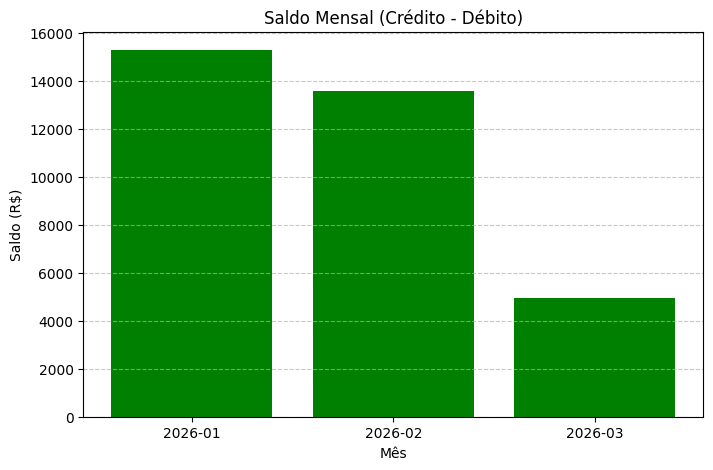

In [3]:
# CÉLULA 3: Requisitos Opcionais (Pandas e Matplotlib)
import pandas as pd
import matplotlib.pyplot as plt

print("--- EXECUTANDO ANÁLISE COM PANDAS (REQUISITO OPCIONAL) ---\n")

# RO1: Análise com Pandas
df = pd.read_csv("transacoes.csv")
# Limpeza rápida simulando as validações
df = df.dropna(subset=['id', 'cliente_id'])
df = df[df['tipo'].isin(['credito', 'debito'])]
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
df = df[df['valor'] > 0]
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df.dropna(subset=['data', 'valor'])

# Agrupamento
df['mes'] = df['data'].dt.to_period('M')
resumo_pandas = df.groupby(['mes', 'tipo'])['valor'].sum().unstack(fill_value=0)
resumo_pandas['saldo'] = resumo_pandas.get('credito', 0) - resumo_pandas.get('debito', 0)

print("Resumo obtido via Pandas:")
print(resumo_pandas)

# RO2: Visualização com Matplotlib (Opção A: Gráfico de barras com saldo mensal)
plt.figure(figsize=(8, 5))
meses = resumo_pandas.index.astype(str)
saldos = resumo_pandas['saldo']

plt.bar(meses, saldos, color=['green' if s > 0 else 'red' for s in saldos])
plt.title('Saldo Mensal (Crédito - Débito)')
plt.xlabel('Mês')
plt.ylabel('Saldo (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salva a imagem conforme exigido
plt.savefig('grafico.png')
print("\nGráfico salvo como 'grafico.png'.")
plt.show()